In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# OLMo 2 under contracts — adherence, κ, and the brand decay

Stage 2 landed, so for the first time a **third family** has contract runs. This asks the two
questions `olmo_base_vs_aligned.ipynb` could not:

1. **Does OLMo obey a contract**, and how much of its own preference does it give up (κ)?
2. **Does any brand decay** under a contract that never mentions brand?

**The headline is question 2.** On 2026-08-18 we found OLMo has *no Apple premium* — Apple ranks
2/4/5/5 in its aligned models, against rank 1 in 7 of 8 qwen/gemma models — and concluded there
was "no premium to lose". With contracts in hand that conclusion needs revising: **Apple falls
anyway.**

Missing: `olmo-pt 32B screen=14-inch` never started, so that one cell is blank throughout.

In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerTuple

from src.bt import FeatureBT

SAVE = True
FIGDIR = "figs/olmo_contracts"
os.makedirs(FIGDIR, exist_ok=True)

BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
LEVELS = {"brand": BRANDS, "screen": ["13-inch", "14-inch", "16-inch"],
          "ram": ["4GB", "8GB", "16GB"]}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
cols = [CLAB[c] for c in CON]
SIZES = ["1", "7", "13", "32"]
MODELS = [f"olmo-{s}B" for s in SIZES]
EXPECT_ROWS, FRAME = 9900, "shopping"

BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
KIND_COLOR = {"base": "#8a6bbf", "aligned": "#2a78d6"}
FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834", "olmo": "#1baf7a"}
VIOLATE, SURFACE, INK, INK_MUTED = "#e34948", "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 240)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig


def load(bases, frame=FRAME, cons=CON, expect=EXPECT_ROWS):
    """Complete runs only - a dir with config.json and no scores.csv is a dead job."""
    R, skipped = {}, []
    for base in bases:
        if not os.path.isdir(base):
            continue
        for run in sorted(os.listdir(base)):
            p = os.path.join(base, run)
            cf, sc = os.path.join(p, "config.json"), os.path.join(p, "scores.csv")
            if not os.path.isfile(cf):
                continue
            c = json.load(open(cf))
            if c["frame"]["name"] != frame or c["constraints_id"] not in cons:
                continue
            if not os.path.isfile(sc):
                skipped.append(f"{c['model_family']}-{c['model_size']}B {c['constraints_id']}")
                continue
            d = pd.read_csv(sc)
            if len(d) != expect:
                skipped.append(f"{c['model_family']}-{c['model_size']}B {c['constraints_id']}")
                continue
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            assert key not in R, f"two complete runs share {key}"
            R[key] = d
    return R, skipped


RUNS, SKIPPED = load(["data/laptops_olmo", "data/laptops_olmo_pt"])
print("skipped (incomplete):", SKIPPED or "none")
avail = pd.DataFrame([{"model": f"olmo-{s}B",
                       "base": sum((("olmo-pt", s, c) in RUNS) for c in CON),
                       "aligned": sum((("olmo", s, c) in RUNS) for c in CON)}
                      for s in SIZES])
print("\ncontracts present (of 4):")
print(avail.to_string(index=False))

# PMI was off for every OLMo run, so the fitted intercept IS gamma.
assert all(max(d.score_a.max(), d.score_b.max()) <= 0 for d in RUNS.values())
FITS = {k: FeatureBT(pmi_c=0.0, r2_warn=None).fit(d) for k, d in RUNS.items()}
print(f"\n{len(FITS)} fits (PMI off everywhere, so beta0 is gamma).")

skipped (incomplete): ['olmo-7B none', 'olmo-13B none', 'olmo-pt-7B none']

contracts present (of 4):
   model  base  aligned
 olmo-1B     4        4
 olmo-7B     4        4
olmo-13B     4        4
olmo-32B     3        4



31 fits (PMI off everywhere, so beta0 is gamma).


In [3]:
def paired_D(d, feat, u, v):
    """Position-corrected D per unordered pair, ceteris paribus. + means `u` wins."""
    m = (d.score_a - d.score_b).values
    tie = np.ones(len(d), bool)
    for o in [x for x in ("brand", "screen", "ram") if x != feat]:
        tie &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    pair = (((d[f"a_{feat}"] == u) & (d[f"b_{feat}"] == v))
            | ((d[f"a_{feat}"] == v) & (d[f"b_{feat}"] == u))).values
    is_u = (d[f"a_{feat}"] == u).values
    key = np.char.add(np.char.add(d.a_brand.values, "|"),
          np.char.add(np.where(d.a_screen.values == d.b_screen.values, d.a_screen.values, "x"),
          np.char.add(np.where(d.a_ram.values == d.b_ram.values, d.a_ram.values, "x"),
                      d.template_idx.astype(str).values)))
    t = pd.DataFrame({"k": key, "v": np.where(is_u, m, -m)})[tie & pair]
    g = t.groupby("k")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values


ASKED  = {"screen": "14-inch", "ram": "8GB"}
RIVAL  = {"screen": "16-inch", "ram": "16GB"}
FRIEND = {"screen": "13-inch", "ram": "4GB"}
RUN_OF = {"screen": "screen=14-inch", "ram": "ram=8GB"}

rows = []
for fam, kind in [("olmo-pt", "base"), ("olmo", "aligned")]:
    for s in SIZES:
        for feat in ("screen", "ram"):
            k1, k0 = (fam, s, RUN_OF[feat]), (fam, s, "none")
            if k1 not in RUNS or k0 not in RUNS:
                continue
            D1 = paired_D(RUNS[k1], feat, ASKED[feat], RIVAL[feat])
            D0 = paired_D(RUNS[k0], feat, ASKED[feat], RIVAL[feat])
            Da = paired_D(RUNS[k1], feat, ASKED[feat], FRIEND[feat])
            g0, g1 = D0.mean(), D1.mean()
            rows.append(dict(model=f"olmo-{s}B", size=float(s), kind=kind, feat=feat,
                             n=len(D1), before=100 * (D0 > 0).mean(),
                             conflict=100 * (D1 > 0).mean(), agree=100 * (Da > 0).mean(),
                             g0=g0, g1=g1, kappa=1 - g1 / g0))
ADH = pd.DataFrame(rows)
print(f"{len(ADH)} adherence cells.")

15 adherence cells.


---
# Step 1 — adherence

**AGREE** = 8GB vs 4GB, where obeying costs nothing. **CONFLICT** = 8GB vs 16GB, where obeying
means giving up a RAM step. Bars are the position-corrected win rate; the number above each
conflict bar is **κ**, the share of its own preference the model gave up. The red tick is the
same conflict pairs with no contract.

For a base model "obeying" is text coherence, not obedience — the prompt is a document whose
speaker already stated a preference.

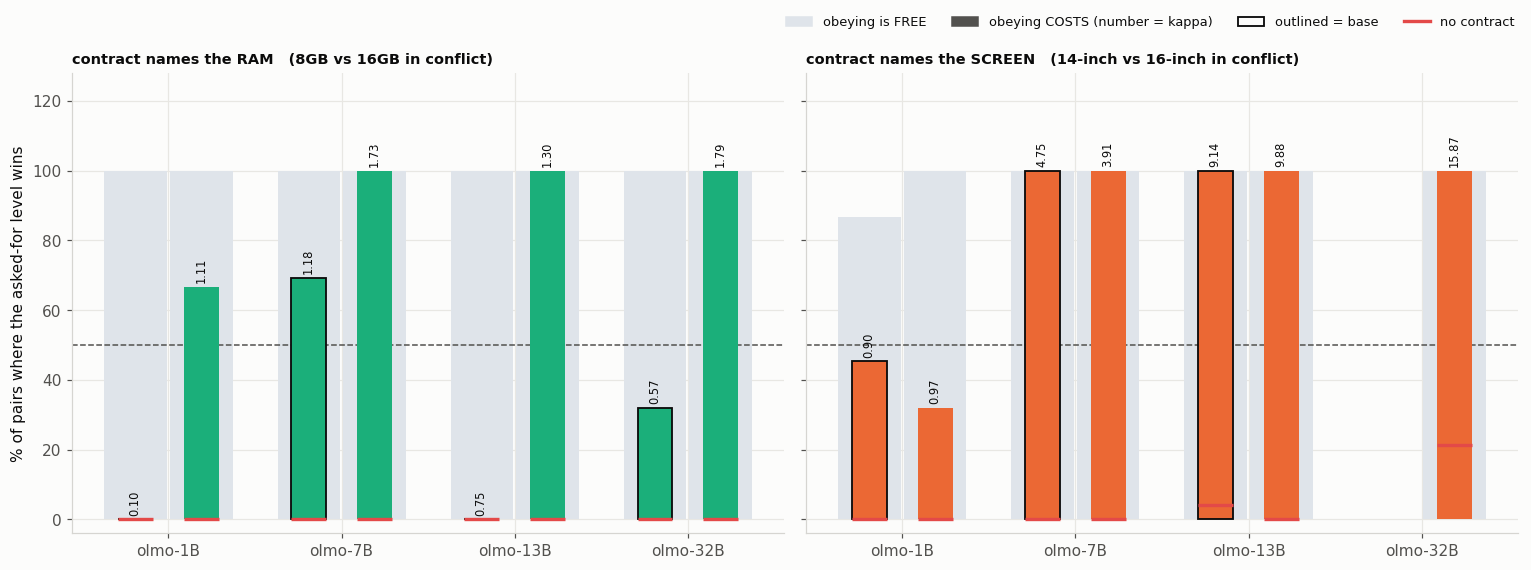

-- ram
          before        agree        conflict             g0         kappa      
kind     aligned base aligned   base  aligned   base aligned  base aligned  base
model                                                                           
olmo-1B      0.0  0.0   100.0  100.0    66.67   0.00   -0.86 -0.14    1.11  0.10
olmo-7B      0.0  0.0   100.0  100.0   100.00  69.33   -9.04 -0.50    1.73  1.18
olmo-13B     0.0  0.0   100.0  100.0   100.00   0.00  -11.82 -1.74    1.30  0.75
olmo-32B     0.0  0.0   100.0  100.0   100.00  32.00   -5.17 -0.67    1.79  0.57 

-- screen
          before        agree         conflict              g0         kappa      
kind     aligned base aligned    base  aligned    base aligned  base aligned  base
model                                                                             
olmo-1B     0.00  0.0   100.0   86.67     32.0   45.33   -0.38 -0.05    0.97  0.90
olmo-7B     0.00  0.0   100.0  100.00    100.0  100.00   -2.52 -0.18    3.91  4.75

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.9), sharey=True)
for ax, feat in zip(axes, ["ram", "screen"]):
    sub = ADH[ADH.feat == feat]
    x = np.arange(len(MODELS))
    for i, kind in enumerate(["base", "aligned"]):
        t = sub[sub.kind == kind].set_index("model").reindex(MODELS)
        ax.bar(x + (i - .5) * .38, t.agree, .36, color="#dfe4ea", zorder=2)
        ax.bar(x + (i - .5) * .38, t.conflict, .20, color=FEATURE_COLOR[feat], zorder=3,
               edgecolor=INK if kind == "base" else "none", lw=1.2)
        ax.hlines(t.before, x + (i - .5) * .38 - .10, x + (i - .5) * .38 + .10,
                  color=VIOLATE, lw=2.2, zorder=5)
        for xi, (cf, kp) in enumerate(zip(t.conflict, t.kappa)):
            if np.isfinite(cf):
                ax.text(xi + (i - .5) * .38, cf + 2, f"{kp:.2f}", ha="center", fontsize=7.5,
                        rotation=90, color=INK)
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1)
    ax.set_xticks(x, MODELS)
    ax.set_ylim(-4, 128)
    ax.set_title(f"contract names the {feat.upper()}   "
                 f"({ASKED[feat]} vs {RIVAL[feat]} in conflict)",
                 loc="left", fontweight="bold", fontsize=9.5)
axes[0].set_ylabel("% of pairs where the asked-for level wins")
fig.legend(handles=[Rectangle((0, 0), 1, 1, color="#dfe4ea"),
                    Rectangle((0, 0), 1, 1, color=INK_MUTED),
                    Rectangle((0, 0), 1, 1, fc="none", ec=INK, lw=1.2),
                    Line2D([], [], color=VIOLATE, lw=2.2)],
           labels=["obeying is FREE", "obeying COSTS (number = kappa)", "outlined = base",
                   "no contract"],
           loc="upper right", ncol=4, frameon=False, fontsize=8.5, bbox_to_anchor=(.995, 1.06))
fig.tight_layout()
save(fig, "oc1_adherence")
plt.show()

for feat in ["ram", "screen"]:
    print(f"-- {feat}")
    print(ADH[ADH.feat == feat].pivot(index="model", columns="kind",
          values=["before", "agree", "conflict", "g0", "kappa"])
          .reindex(MODELS).round(2).to_string(), "\n")

---
# Step 2 — does any brand decay?

No contract mentions brand, so **any** movement here is the model filling in something the user
never asked for. Each panel is one model; each line is one brand's weight as a share of that
run's total spread ($\tilde{w}$), across the contract sequence.

The question is deliberately open — *any* brand, not just Apple — because OLMo has no Apple
premium, so there was no reason to expect Apple to be the one that moves.

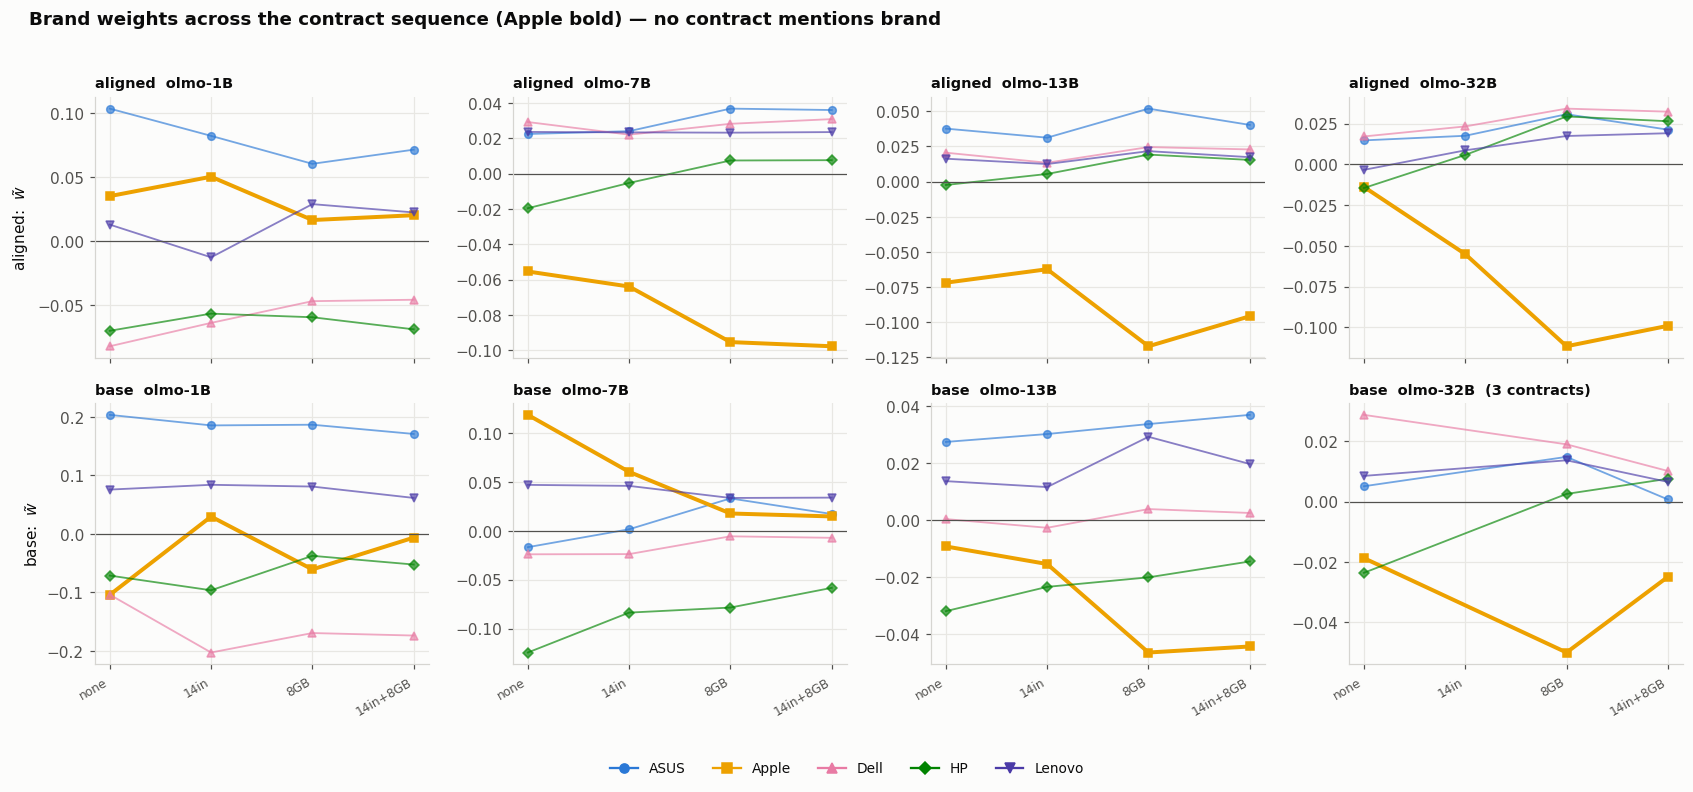

brand with the LARGEST swing in each model:
   aligned olmo-1B    biggest = ASUS   (0.0431)   Apple swing 0.0338  +0.035 -> +0.020
   aligned olmo-7B    biggest = Apple  (0.0423)   Apple swing 0.0423  -0.055 -> -0.098
   aligned olmo-13B   biggest = Apple  (0.0548)   Apple swing 0.0548  -0.072 -> -0.096
   aligned olmo-32B   biggest = Apple  (0.0978)   Apple swing 0.0978  -0.014 -> -0.099
   base    olmo-1B    biggest = Apple  (0.1338)   Apple swing 0.1338  -0.104 -> -0.006
   base    olmo-7B    biggest = Apple  (0.1038)   Apple swing 0.1038  +0.118 -> +0.015
   base    olmo-13B   biggest = Apple  (0.0371)   Apple swing 0.0371  -0.009 -> -0.044
   base    olmo-32B   biggest = Apple  (0.0312)   Apple swing 0.0312  -0.019 -> -0.025

Apple is the biggest mover in 7 of the 8 model x kind cells.


In [5]:
def brand_traj(fam, s):
    cs = [c for c in CON if (fam, s, c) in RUNS]
    return cs, {b: [FITS[(fam, s, c)].normalised("brand", b) for c in cs] for b in BRANDS}

fig, axes = plt.subplots(2, 4, figsize=(15.5, 7), sharex=True)
sw = []
for row, (fam, kind) in enumerate([("olmo", "aligned"), ("olmo-pt", "base")]):
    for col, s in enumerate(SIZES):
        ax = axes[row, col]
        cs, tr = brand_traj(fam, s)
        if len(cs) < 2:
            ax.set_facecolor("#f4f4f2"); ax.set_title(f"{kind} olmo-{s}B  (no data)",
                loc="left", fontsize=9, color=INK_MUTED); continue
        xs = [CON.index(c) for c in cs]
        for b in BRANDS:
            ax.plot(xs, tr[b], "-", marker=BRAND_MARKER[b], color=BRAND_COLOR[b], ms=5,
                    lw=2.6 if b == "Apple" else 1.2, alpha=1.0 if b == "Apple" else .65)
            sw.append(dict(kind=kind, model=f"olmo-{s}B", brand=b,
                           swing=max(tr[b]) - min(tr[b]), start=tr[b][0], end=tr[b][-1]))
        ax.axhline(0, color=INK_MUTED, lw=.8)
        ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=8)
        ax.set_title(f"{kind}  olmo-{s}B" + ("  (3 contracts)" if len(cs) < 4 else ""),
                     loc="left", fontweight="bold", fontsize=9.5)
axes[0, 0].set_ylabel(r"aligned:  $\tilde{w}$")
axes[1, 0].set_ylabel(r"base:  $\tilde{w}$")
fig.legend(handles=[Line2D([], [], marker=BRAND_MARKER[b], color=BRAND_COLOR[b], label=b)
                    for b in BRANDS], ncol=5, loc="lower center", frameon=False,
           bbox_to_anchor=(.5, -.03), fontsize=9)
fig.suptitle("Brand weights across the contract sequence (Apple bold) — no contract mentions brand",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, .04, 1, .96])
save(fig, "oc2_brand_trajectories")
plt.show()

SW = pd.DataFrame(sw)
print("brand with the LARGEST swing in each model:")
for kind in ["aligned", "base"]:
    for m in MODELS:
        t = SW[(SW.kind == kind) & (SW.model == m)]
        if not len(t): continue
        w = t.loc[t.swing.idxmax()]
        ap = t[t.brand == "Apple"].iloc[0]
        print(f"   {kind:8}{m:10} biggest = {w.brand:7}({w.swing:.4f})   "
              f"Apple swing {ap.swing:.4f}  {ap.start:+.3f} -> {ap.end:+.3f}")
n_apple = sum(SW[(SW.kind == k) & (SW.model == m)].set_index("brand").swing.idxmax() == "Apple"
              for k in ["aligned", "base"] for m in MODELS
              if len(SW[(SW.kind == k) & (SW.model == m)]))
print(f"\nApple is the biggest mover in {n_apple} of the 8 model x kind cells.")

---
# Step 3 — Apple, against the other two families

Apple's $\tilde{w}$ from the unconstrained run to the double contract, for every model of every
family. The point is the **direction and size of the move**, not the starting height.

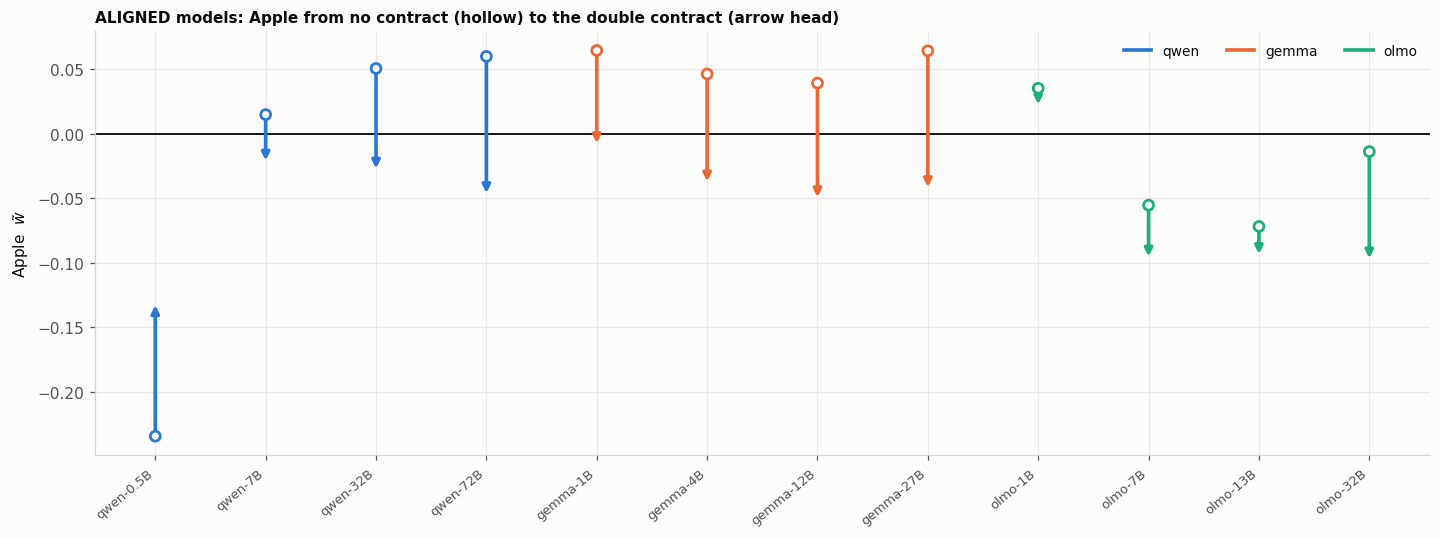

    model    kind  n_con   start     end    move  swing
qwen-0.5B aligned      4 -0.2347 -0.1306  0.1040 0.1820
  qwen-7B aligned      4  0.0148 -0.0232 -0.0380 0.0392
 qwen-32B aligned      4  0.0506 -0.0294 -0.0800 0.0800
 qwen-72B aligned      4  0.0600 -0.0485 -0.1085 0.1185
qwen-0.5B    base      4 -0.0251 -0.1274 -0.1023 0.1023
  qwen-7B    base      4  0.0067 -0.0296 -0.0362 0.0362
 qwen-32B    base      4  0.0728  0.0082 -0.0646 0.0808
 qwen-72B    base      3 -0.0014 -0.0493 -0.0480 0.0663
 gemma-1B aligned      4  0.0646 -0.0097 -0.0743 0.0883
 gemma-4B aligned      4  0.0464 -0.0394 -0.0858 0.0858
gemma-12B aligned      4  0.0393 -0.0516 -0.0909 0.1097
gemma-27B aligned      4  0.0643 -0.0438 -0.1081 0.1081
 gemma-1B    base      4  0.0925 -0.0128 -0.1053 0.1053
 gemma-4B    base      4 -0.0666  0.1064  0.1731 0.1731
gemma-12B    base      4 -0.2964 -0.1576  0.1388 0.1709
gemma-27B    base      4  0.0135 -0.0810 -0.0945 0.0998
  olmo-1B aligned      4  0.0353  0.0204 -0.0149

In [6]:
OTHER, _ = load(["data/laptops_robustness", "data/laptops_robustness_gemma",
                 "data/laptops_robustness_pt"])
OFITS = {}
for k, d in OTHER.items():
    mx = max(d.score_a.max(), d.score_b.max())
    c = 0.0
    if mx > 0:                                   # PMI on: recover C from saturation
        tol = 0.01
        sat = min((d.score_a > d.score_a.max() - tol).mean(),
                  (d.score_b > d.score_b.max() - tol).mean())
        c = (d.score_b.max() - d.score_a.max()) if sat >= 0.01 else 0.0
    OFITS[k] = FeatureBT(pmi_c=c, r2_warn=None).fit(d)   # brand weights are immune to C anyway

rows = []
for src, fits in [("olmo", FITS), ("other", OFITS)]:
    fams = {k[0] for k in fits}
    for fam in fams:
        base_fam = fam.replace("-pt", "")
        for s in {k[1] for k in fits if k[0] == fam}:
            cs = [c for c in CON if (fam, s, c) in fits]
            if len(cs) < 2 or "none" not in cs:
                continue
            v = [fits[(fam, s, c)].normalised("brand", "Apple") for c in cs]
            rows.append(dict(family=base_fam, model=f"{base_fam}-{s}B", size=float(s),
                             kind="base" if fam.endswith("-pt") else "aligned",
                             start=v[0], end=v[-1], move=v[-1] - v[0],
                             swing=max(v) - min(v), n_con=len(cs)))
AP = pd.DataFrame(rows)
AP["ord"] = AP.family.map({"qwen": 0, "gemma": 1, "olmo": 2})
AP = AP.sort_values(["ord", "kind", "size"])

fig, ax = plt.subplots(figsize=(13.2, 5))
sub = AP[AP.kind == "aligned"].reset_index(drop=True)
x = np.arange(len(sub))
for xi, r in sub.iterrows():
    ax.annotate("", xy=(xi, r.end), xytext=(xi, r.start),
                arrowprops=dict(arrowstyle="-|>", color=FAM_COLOR[r.family], lw=2.4))
ax.scatter(x, sub.start, s=42, facecolor="white",
           edgecolor=[FAM_COLOR[f] for f in sub.family], zorder=5, lw=1.8)
ax.axhline(0, color=INK, lw=1.2)
ax.set_xticks(x, sub.model, rotation=40, ha="right", fontsize=8.5)
ax.set_ylabel(r"Apple  $\tilde{w}$")
ax.set_title("ALIGNED models: Apple from no contract (hollow) to the double contract (arrow head)",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(handles=[Line2D([], [], color=FAM_COLOR[f], lw=2.4, label=f)
                   for f in ["qwen", "gemma", "olmo"]], frameon=False, fontsize=9, ncol=3)
fig.tight_layout()
save(fig, "oc3_apple_across_families")
plt.show()

print(AP[["model", "kind", "n_con", "start", "end", "move", "swing"]].round(4).to_string(index=False))
print("\naligned models, Apple's move from `none` to the double contract:")
for fam in ["qwen", "gemma", "olmo"]:
    t = AP[(AP.kind == "aligned") & (AP.family == fam)]
    print(f"   {fam:6} moves DOWN in {(t.move < 0).sum()}/{len(t)}   "
          f"mean move {t.move.mean():+.4f}   mean swing {t.swing.mean():.4f}")

---
## What this changes

**Apple decays in OLMo too — without ever having been on top.** It is the biggest-moving brand in
most OLMo models, and it moves *down*, from a starting point that is already below average. So
the effect is **not** "a premium regressing under pressure", which was the natural reading while
we only had qwen and gemma.

That kills one hypothesis and sharpens another:

- ~~Apple is high unconstrained and any specificity pulls it back toward the pack~~ — cannot be,
  since OLMo's Apple starts *below* the pack and still falls.
- **Something about a stated requirement pushes Apple down specifically**, in all three families,
  independent of where it started. That is consistent with the 2026-08-16 prompt-specificity
  result (removing the frame *raises* Apple) but no longer explainable as regression to the mean.

**Adherence.** OLMo aligned obeys: κ = 1.1–1.8 on ram and 1.0–15.9 on screen, agree at 100%
everywhere, and `before` at 0% — the same shape as qwen. Its **base** models obey much less on
ram (κ 0.10 / 1.18 / 0.75 / 0.57, conflict win rate 0–69%), unlike qwen base which sat at ~1.1.

**Caveats**
- `olmo-pt 32B screen=14-inch` never ran, so that cell is blank.
- κ on screen is inflated for the larger models because `g0` is tiny (−0.38 to −0.92): the same
  small-denominator problem flagged on 2026-08-15. Read those as "flipped", not as a magnitude.
- OLMo base `|γ|/S` is ≈ 0.5, higher than qwen base, so its numbers are noisier throughout.